## DATA WRANGLING AND DATA ANALYSIS

In [3]:
from datetime import timedelta
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
#import datetime as dt
aus_sales_df = pd.read_csv('AusApparalSales4thQrt2020.csv')
min_max_scaler = MinMaxScaler()
std_scaler = StandardScaler()
# Data wrangling
print("is nan value count" ,  aus_sales_df.isna().sum().sum())
print("describe data", aus_sales_df.describe())
print("info data", aus_sales_df.info())
print("shape of sales data", aus_sales_df.shape)
print("columns of sales data", aus_sales_df.columns)
print("data types of sales data", aus_sales_df.dtypes)

# Function to get quarter from month
def get_quarter(month):
    if month in ['January', 'February', 'March']:
        return 'Q1'
    elif month in ['April', 'May', 'June']:
        return 'Q2'
    elif month in ['July', 'August', 'September']:
        return 'Q3'
    elif month in ['October', 'November', 'December']:
        return 'Q4'
    else:
        return None

# Date Feature Extraction
aus_sales_df['formatted_date'] = pd.to_datetime(aus_sales_df['Date'])
aus_sales_df['day'] = aus_sales_df['formatted_date'].dt.day_name()
aus_sales_df['month'] = aus_sales_df['formatted_date'].dt.month_name()
aus_sales_df['year'] = aus_sales_df['formatted_date'].dt.year
aus_sales_df['week'] = (aus_sales_df['formatted_date'].dt.day - 1) // 7 + 1

# Quarter Extraction
aus_sales_df['quarter'] =aus_sales_df['formatted_date'].dt.month_name().apply(get_quarter)
# Min-Max Scaling
aus_sales_df['unit_scaled'] = min_max_scaler.fit_transform(aus_sales_df[['Unit']])
# Standard Scaling
aus_sales_df['sales_standard_scaled'] = std_scaler.fit_transform(aus_sales_df[['Sales']])




aus_sales_df['Week_Start'] = aus_sales_df['formatted_date'].dt.to_period('W-MON').dt.start_time
aus_sales_df['Week_End'] = aus_sales_df['Week_Start'] + timedelta(days=6)
aus_sales_df['Week_Label'] = aus_sales_df['Week_Start'].dt.strftime('%Y-%m-%d') + '--To--' + aus_sales_df['Week_End'].dt.strftime('%Y-%m-%d')

aus_sales_df.head()





is nan value count 0
describe data               Unit          Sales
count  7560.000000    7560.000000
mean     18.005423   45013.558201
std      12.901403   32253.506944
min       2.000000    5000.000000
25%       8.000000   20000.000000
50%      14.000000   35000.000000
75%      26.000000   65000.000000
max      65.000000  162500.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB
info data None
shape of sales data (7560, 6)
columns of sales data Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')
data types of sales data Date     object
Time     object
State    objec

,Date,Time,State,Group,Unit,Sales,formatted_date,day,month,year,week,quarter,unit_scaled,sales_standard_scaled,Week_Start,Week_End,Week_Label
0,1-Oct-2020,Morning,WA,Kids,8,20000,2020-10-01,Thursday,October,2020,1,Q4,0.095238,-0.775581,2020-09-29,2020-10-05,2020-09-29--To--2020-10-05
1,1-Oct-2020,Morning,WA,Men,8,20000,2020-10-01,Thursday,October,2020,1,Q4,0.095238,-0.775581,2020-09-29,2020-10-05,2020-09-29--To--2020-10-05
2,1-Oct-2020,Morning,WA,Women,4,10000,2020-10-01,Thursday,October,2020,1,Q4,0.031746,-1.085645,2020-09-29,2020-10-05,2020-09-29--To--2020-10-05
3,1-Oct-2020,Morning,WA,Seniors,15,37500,2020-10-01,Thursday,October,2020,1,Q4,0.206349,-0.232969,2020-09-29,2020-10-05,2020-09-29--To--2020-10-05
4,1-Oct-2020,Afternoon,WA,Kids,3,7500,2020-10-01,Thursday,October,2020,1,Q4,0.015873,-1.163162,2020-09-29,2020-10-05,2020-09-29--To--2020-10-05


## # Calculate descriptive statistics for Sales and Unit columns

In [7]:
mean_vals = aus_sales_df[['Unit', 'Sales']].mean()
mode_vals = aus_sales_df[['Unit', 'Sales']].mode()
std_vals = aus_sales_df[['Unit', 'Sales']].std()
median_vals = aus_sales_df[['Unit', 'Sales']].median()

# print labeled results
print("Mean:\n", mean_vals, "\n")
print("Mode:\n", mode_vals.to_string(index=False), "\n")
print("Std Dev:\n", std_vals, "\n")
print("Median:\n", median_vals, "\n")


Mean:
 Unit        18.005423
Sales    45013.558201
dtype: float64 

Mode:
  Unit  Sales
    9  22500 

Std Dev:
 Unit        12.901403
Sales    32253.506944
dtype: float64 

Median:
 Unit        14.0
Sales    35000.0
dtype: float64 

       Date       Time State    Group  Unit  Sales formatted_date       day    month  year  week quarter  unit_scaled  sales_standard_scaled Week_Start   Week_End                 Week_Label
 1-Oct-2020    Morning    WA     Kids     8  20000     2020-10-01  Thursday  October  2020     1      Q4     0.095238              -0.775581 2020-09-29 2020-10-05 2020-09-29--To--2020-10-05
 1-Oct-2020    Morning    WA      Men     8  20000     2020-10-01  Thursday  October  2020     1      Q4     0.095238              -0.775581 2020-09-29 2020-10-05 2020-09-29--To--2020-10-05
 1-Oct-2020    Morning    WA    Women     4  10000     2020-10-01  Thursday  October  2020     1      Q4     0.031746              -1.085645 2020-09-29 2020-10-05 2020-09-29--To--2020-10-05
 1-Oct

## GROUP BY

In [54]:
# State and Group wise sales for all categories
print("========================= State and Group wise sum =================")
state_group_sum = aus_sales_df.groupby(['State','Group'])[['Unit','Sales']].sum().reset_index()
print(state_group_sum)
print("========================= State and Group wise mean =================")
# State and Group wise mean, std, median
state_group_mean = aus_sales_df.groupby(['State','Group'])[['Unit','Sales']].mean().reset_index()
print(state_group_mean)
print("========================= State and Group wise std =================")
state_group_std = aus_sales_df.groupby(['State','Group'])[['Unit','Sales']].std().reset_index()
print(state_group_std)
print("========================= State and Group wise median =================")
state_group_median = aus_sales_df.groupby(['State','Group'])[['Unit','Sales']].median().reset_index()
print(state_group_median)

group_sale = (
    aus_sales_df.groupby("Group")["Sales"]
      .sum()
      .reset_index()
)
print("========= Group Sales =====")
print(group_sale)

========================= State and Group wise sum =================
   State     Group   Unit     Sales
0    NSW      Kids   7435  18587500
1    NSW       Men   7609  19022500
2    NSW   Seniors   7275  18187500
3    NSW     Women   7669  19172500
4     NT      Kids   2280   5700000
5     NT       Men   2305   5762500
6     NT   Seniors   2186   5465000
7     NT     Women   2261   5652500
8    QLD      Kids   3404   8510000
9    QLD       Men   3357   8392500
10   QLD   Seniors   3276   8190000
11   QLD     Women   3330   8325000
12    SA      Kids   5806  14515000
13    SA       Men   5862  14655000
14    SA   Seniors   5887  14717500
15    SA     Women   5988  14970000
16   TAS      Kids   2310   5775000
17   TAS       Men   2303   5757500
18   TAS   Seniors   2260   5650000
19   TAS     Women   2231   5577500
20   VIC      Kids  10544  26360000
21   VIC       Men  10563  26407500
22   VIC   Seniors  10526  26315000
23   VIC     Women  10593  26482500
24    WA      Kids   2250   562

## Find the Group with highest and lowest total Sales

In [12]:
# Initialize an empty dictionary to store group sums
group_sales_sum = {}
unique_groups = aus_sales_df['Group'].unique()
type(unique_groups)
# Iterate over each group, filter the DataFrame, and sum Sales
for group in unique_groups:
    group_df = aus_sales_df[aus_sales_df['Group'] == group]
    total_sales = int(group_df['Sales'].sum())
    group_sales_sum[group] = total_sales

#print(group_sales_sum)

sorted_group_sales = sorted(group_sales_sum.items(), key=lambda item: item[1], reverse=True)
highest_group, highest_sales = sorted_group_sales[0]
lowest_group, lowest_sales = sorted_group_sales[-1]

print(f"Highest Sales Group: {highest_group} with Sales: {highest_sales}")
print(f"Lowest Sales Group: {lowest_group} with Sales: {lowest_sales}")

Highest Sales Group:  Men with Sales: 85750000
Lowest Sales Group:  Seniors with Sales: 84037500


Weekly Sales Report

In [33]:

weekly_report = aus_sales_df.groupby(['Week_Label']).agg({
    'Sales': 'sum',
    'Unit': 'sum'
}).reset_index().sort_values(by=['Sales'], ascending=True)

print(weekly_report)

weekly_report_state_group = aus_sales_df.groupby(['Week_Label','State','Group']).agg({
    'Sales': 'sum',
    'Unit': 'sum'
}).reset_index().sort_values(by=['Sales'], ascending=True)

print(weekly_report_state_group)

                    Week_Label     Sales   Unit
13  2020-12-29--To--2021-01-04   9197500   3679
0   2020-09-29--To--2020-10-05  18907500   7563
4   2020-10-27--To--2020-11-02  20797500   8319
5   2020-11-03--To--2020-11-09  21065000   8426
7   2020-11-17--To--2020-11-23  21187500   8475
6   2020-11-10--To--2020-11-16  21242500   8497
8   2020-11-24--To--2020-11-30  21442500   8577
3   2020-10-20--To--2020-10-26  26590000  10636
2   2020-10-13--To--2020-10-19  26805000  10722
1   2020-10-06--To--2020-10-12  26935000  10774
9   2020-12-01--To--2020-12-07  30817500  12327
11  2020-12-15--To--2020-12-21  31247500  12499
12  2020-12-22--To--2020-12-28  32007500  12803
10  2020-12-08--To--2020-12-14  32060000  12824
                     Week_Label State     Group    Sales  Unit
369  2020-12-29--To--2021-01-04    NT       Men   115000    46
371  2020-12-29--To--2021-01-04    NT     Women   125000    50
380  2020-12-29--To--2021-01-04   TAS      Kids   147500    59
389  2020-12-29--To--2021-01

Monthly Sales Report

In [30]:
monthly_report = aus_sales_df.groupby(['month']).agg({
    'Sales': 'sum',
    'Unit': 'sum'
}).reset_index().sort_values(by=['Sales'], ascending=True)

print(monthly_report)


mens_df = aus_sales_df[aus_sales_df['Group'] == ' Men' ]
monthly_report_state_group = mens_df.groupby(['month','State','Group']).agg({
    'Sales': 'sum',
    'Unit': 'sum'
}).reset_index().sort_values(by=['Sales'], ascending=True)



print(monthly_report_state_group)

      month      Sales   Unit
1  November   90682500  36273
2   October  114290000  45716
0  December  135330000  54132
       month State Group     Sales  Unit
8   November    NT   Men   1280000   512
13  November    WA   Men   1332500   533
11  November   TAS   Men   1350000   540
9   November   QLD   Men   1982500   793
18   October   TAS   Men   2035000   814
15   October    NT   Men   2122500   849
20   October    WA   Men   2127500   851
6   December    WA   Men   2292500   917
1   December    NT   Men   2360000   944
4   December   TAS   Men   2372500   949
16   October   QLD   Men   2855000  1142
2   December   QLD   Men   3555000  1422
10  November    SA   Men   3910000  1564
17   October    SA   Men   5087500  2035
7   November   NSW   Men   5490000  2196
3   December    SA   Men   5657500  2263
14   October   NSW   Men   6270000  2508
0   December   NSW   Men   7262500  2905
12  November   VIC   Men   7270000  2908
19   October   VIC   Men   8387500  3355
5   December   VIC 

Yearly Sales Report

In [34]:

print("======================== Yearly sales ======================")

yearly_report = aus_sales_df.groupby(['year']).agg({
    'Sales': 'sum',
    'Unit': 'sum'
}).reset_index().sort_values(by=['Sales'], ascending=True)

print(yearly_report)


print("================= Yearly State and Group wise Sales using pivot ================")
aus_sales_df.pivot_table(index = 'year' , columns = 'Group' , values = 'Sales' , aggfunc = 'sum')



======================== Yearly sales ======================
   year      Sales    Unit
0  2020  340302500  136121
================= Yearly State and Group wise Sales using pivot ================


Group,Kids,Men,Seniors,Women
year,,,,
2020,85072500,85750000,84037500,85442500


In [11]:
state_grouped_df = aus_sales_df.groupby(['State', 'Group','Time'])[['Unit', 'Sales']].sum().reset_index()
state_grouped_df.groupby(['State'])[['Sales']].sum().reset_index().sort_values(by='Sales')

time_group_df =  aus_sales_df.groupby(['Time'])[['Sales']].sum()
time_group_df.reset_index().sort_values(by='Sales')



aus_sales_df.pivot_table(index = 'Time' , columns = 'Group' , values = 'Sales' , aggfunc = 'sum')
#aus_sales_df['Time'].unique()

#kids_df = aus_sales_df[ (aus_sales_df['Group'] == ' Kids') & (aus_sales_df['Time'] == ' Afternoon') ]
#kids_df.groupby(['State'])[['Unit','Sales']].sum().reset_index()
#kids_df['Sales'].sum()

aus_sales_df.head()

mode_value = aus_sales_df['Sales'].mean()
print(mode_value)



45013.5582010582


In [94]:
monthly_report = aus_sales_df.groupby(['year', 'month']).agg({
    'Sales': 'sum',
    'Unit': 'sum'
}).reset_index().sort_values(by=['Sales'], ascending=False)

monthly_report

,year,month,Sales,Unit
0,2020,December,135330000,54132
2,2020,October,114290000,45716
1,2020,November,90682500,36273


## DATA VISUALIZATION

State and Group wise Boxplot

<Axes: xlabel='Group', ylabel='Sales'>

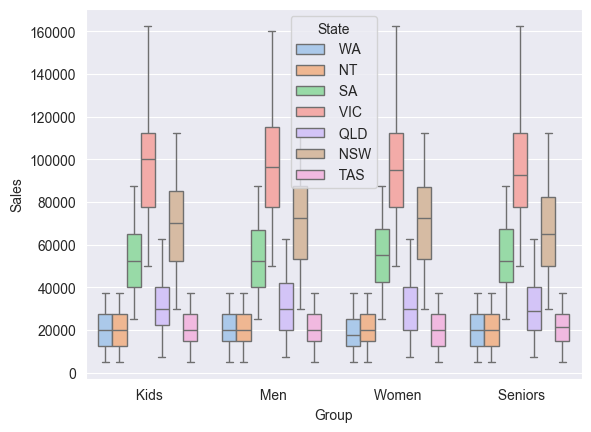

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df = aus_sales_df.copy()

sns.boxplot(x = "Group", y = "Sales",
            hue = "State",
            data = df,
            palette = "pastel")


Group and State wise Boxplot

<Axes: xlabel='State', ylabel='Sales'>

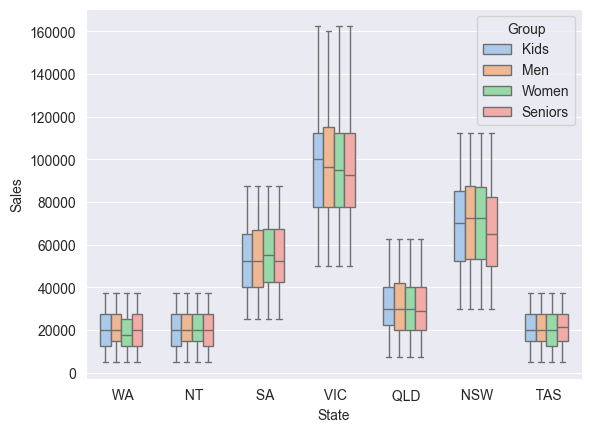

In [8]:

sns.boxplot(x = "State", y = "Sales",
            hue = "Group",
            data = df,
            palette = "pastel", width=0.6 ,dodge=True )




Peak vs Off-Peak Sales Analysis

In [10]:
sales_by_time = aus_sales_df.groupby("Time")["Sales"].sum().reset_index()
print(sales_by_time)
peak = sales_by_time.loc[sales_by_time["Sales"].idxmax()]
off_peak = sales_by_time.loc[sales_by_time["Sales"].idxmin()]
print(f"Peak Sales Time: {peak['Time']} with Sales: {peak['Sales']}")
print(f"Off-Peak Sales Time: {off_peak['Time']} with Sales: {off_peak['Sales']}")



         Time      Sales
0   Afternoon  114007500
1     Evening  112087500
2     Morning  114207500
Peak Sales Time:  Morning with Sales: 114207500
Off-Peak Sales Time:  Evening with Sales: 112087500


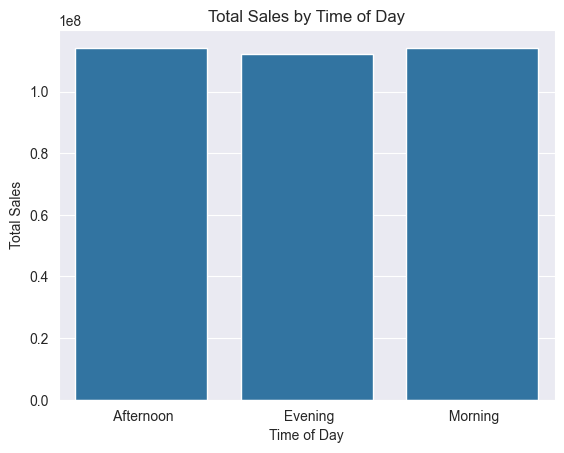

In [12]:

sns.barplot(data=sales_by_time, x="Time", y="Sales")
plt.title("Total Sales by Time of Day")
plt.ylabel("Total Sales")
plt.xlabel("Time of Day")
plt.show()

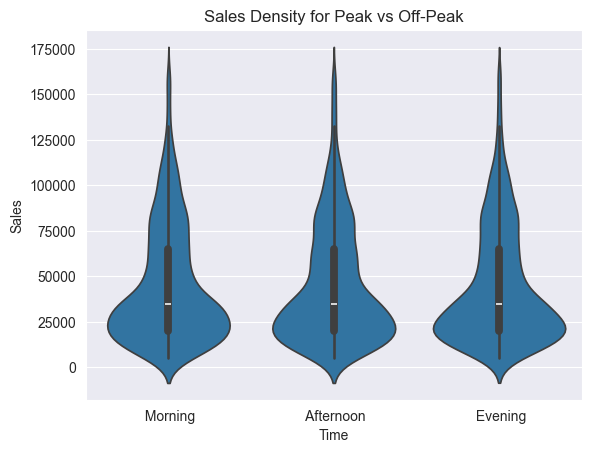

In [13]:

sns.violinplot(data=df, x="Time", y="Sales")
plt.title("Sales Density for Peak vs Off-Peak")
plt.show()

In [15]:
df.columns

Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales', 'formatted_date',
       'day', 'month', 'year', 'week', 'quarter', 'unit_scaled',
       'sales_standard_scaled', 'Week_Start', 'Week_End', 'Week_Label'],
      dtype='object')

Text(0.5, 1.0, 'Daily Sales Trend')

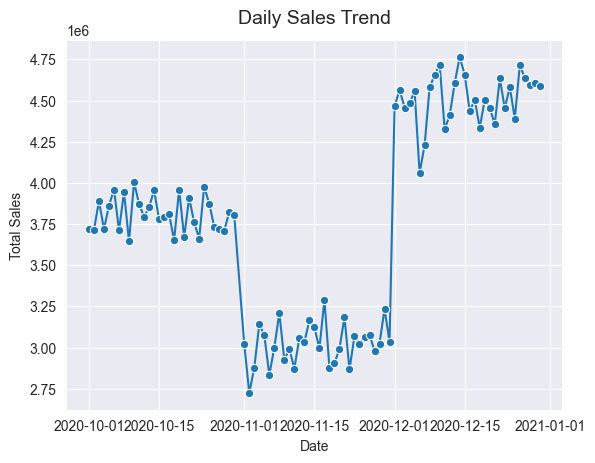

In [29]:
daily_sales = (
    df.groupby("formatted_date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales


line_plot = sns.lineplot(data=daily_sales, x="formatted_date", y="Sales", marker="o")
line_plot.set_xlabel("Date")
line_plot.set_ylabel("Total Sales")
line_plot.set_title("Daily Sales Trend", fontsize=14, pad=12)





In [35]:
weekly_report

,Week_Label,Sales,Unit
13,2020-12-29--To--2021-01-04,9197500,3679
0,2020-09-29--To--2020-10-05,18907500,7563
4,2020-10-27--To--2020-11-02,20797500,8319
5,2020-11-03--To--2020-11-09,21065000,8426
7,2020-11-17--To--2020-11-23,21187500,8475
6,2020-11-10--To--2020-11-16,21242500,8497
8,2020-11-24--To--2020-11-30,21442500,8577
3,2020-10-20--To--2020-10-26,26590000,10636
2,2020-10-13--To--2020-10-19,26805000,10722
1,2020-10-06--To--2020-10-12,26935000,10774


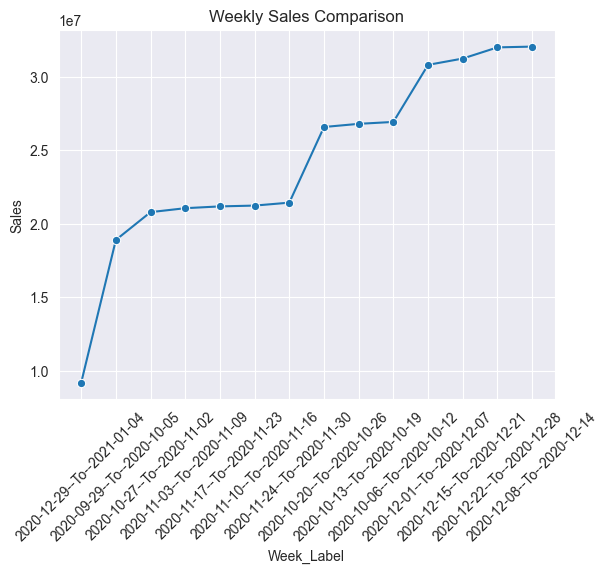

In [44]:

sns.lineplot(data=weekly_report, x="Week_Label", y="Sales", marker="o")
plt.title("Weekly Sales Comparison")
plt.xticks(rotation=45)
plt.show()

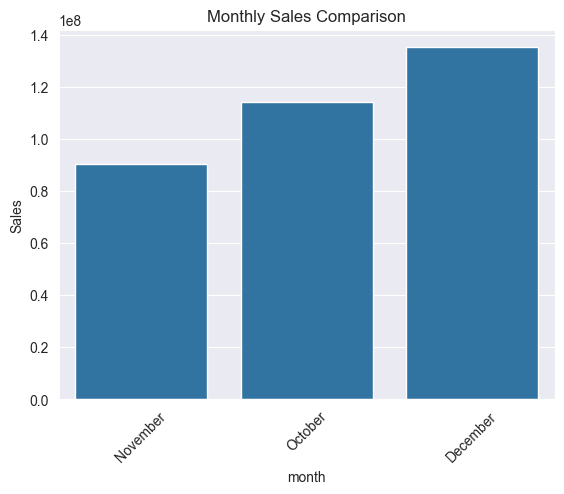

<Axes: xlabel='month', ylabel='Sales'>

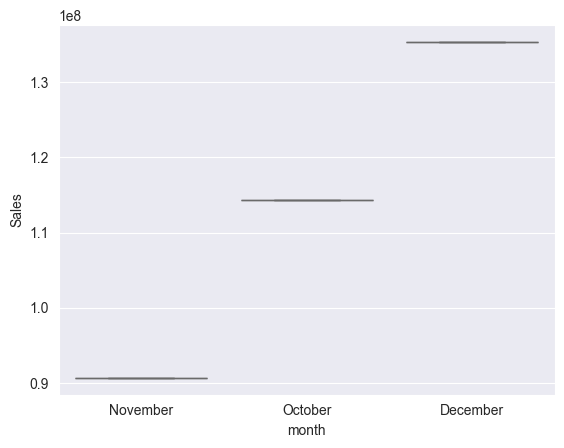

In [57]:
sns.barplot(data=monthly_report, x="month", y="Sales")
plt.title("Monthly Sales Comparison")
plt.xticks(rotation=45)
plt.show()


## QUARTELY / Q4 SALES ANALYSIS

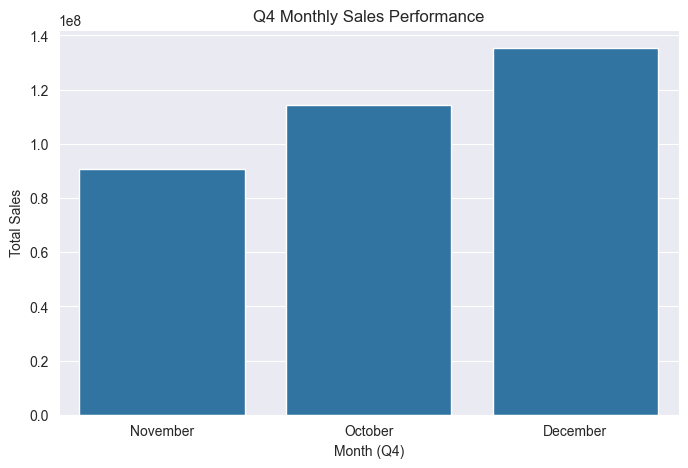

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(data=monthly_report, x="month", y="Sales")
plt.title("Q4 Monthly Sales Performance")
plt.xlabel("Month (Q4)")
plt.ylabel("Total Sales")
plt.show()

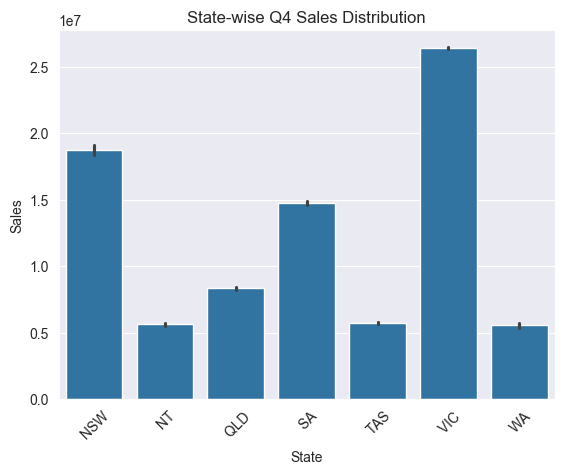

In [52]:
sns.barplot(data=state_group_sum, x="State", y="Sales")
plt.title("State-wise Q4 Sales Distribution")
plt.xticks(rotation=45)
plt.show()

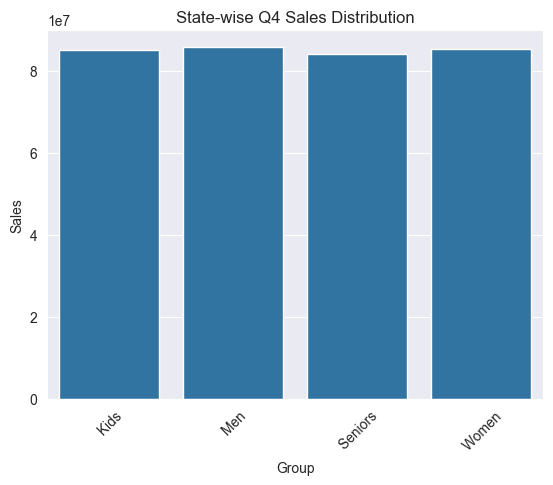

In [55]:
sns.barplot(data=group_sale, x="Group", y="Sales")
plt.title("State-wise Q4 Sales Distribution")
plt.xticks(rotation=45)
plt.show()

I used bar plots  to visualize the sales distribution across different states and groups during Q4. The bar plots helped in comparing total sales